
Testing MLP with hidden_layers=[8], activation=relu


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 0.9333, Test Loss: 0.2152


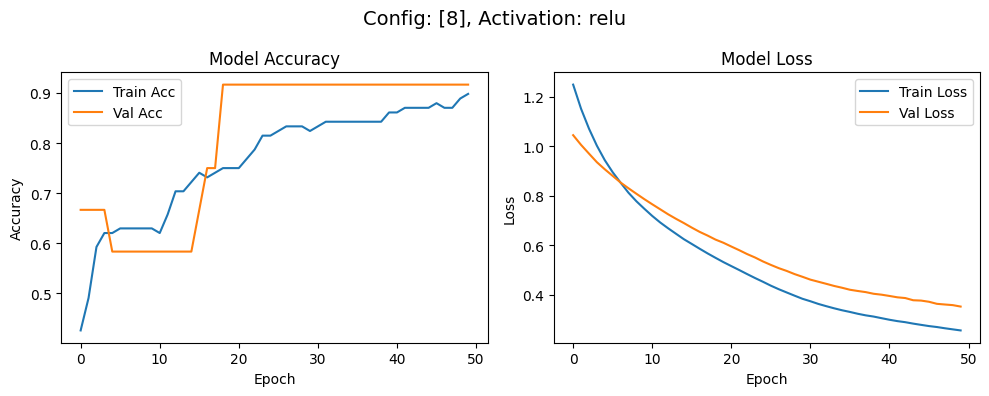


Testing MLP with hidden_layers=[8], activation=tanh
Test Accuracy: 0.9667, Test Loss: 0.1987


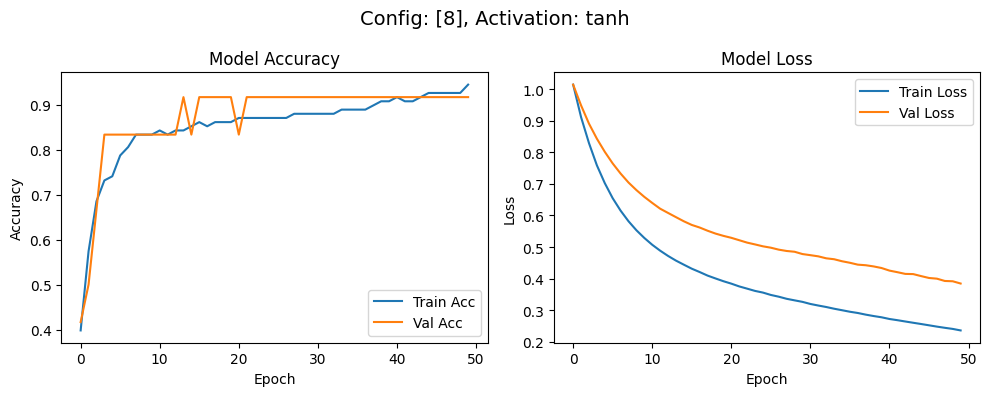


Testing MLP with hidden_layers=[8], activation=sigmoid
Test Accuracy: 0.9333, Test Loss: 0.3989


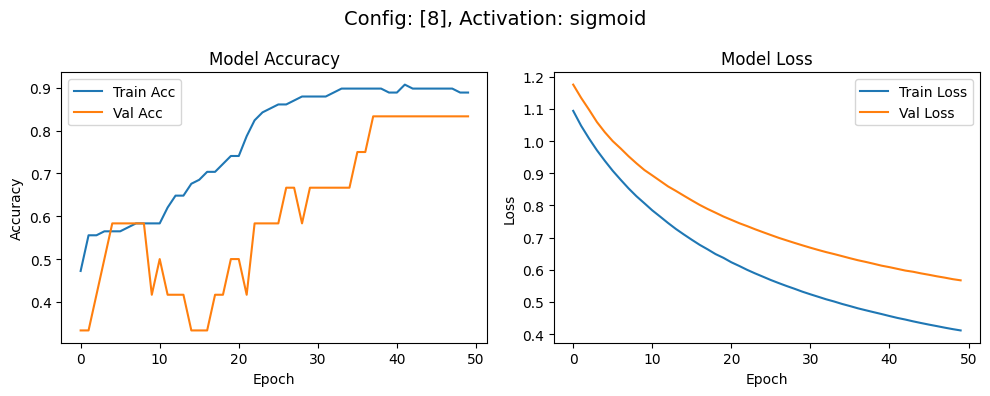


Testing MLP with hidden_layers=[16, 8], activation=relu
Test Accuracy: 1.0000, Test Loss: 0.0870


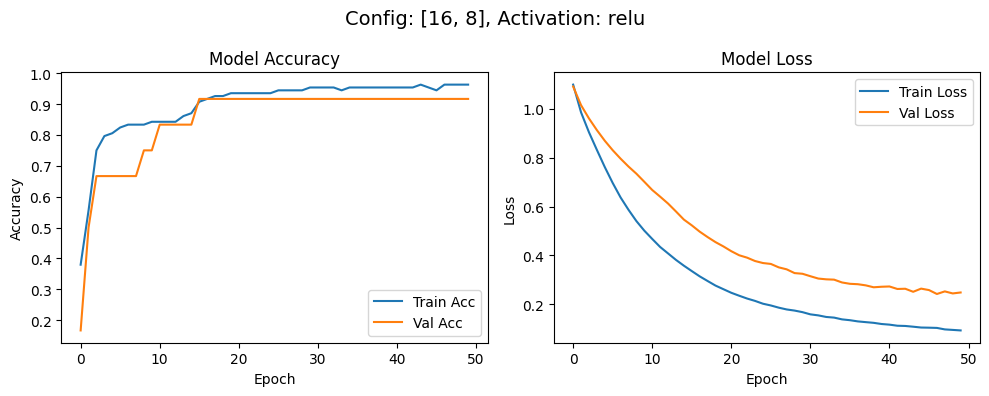


Testing MLP with hidden_layers=[16, 8], activation=tanh
Test Accuracy: 0.9667, Test Loss: 0.0856


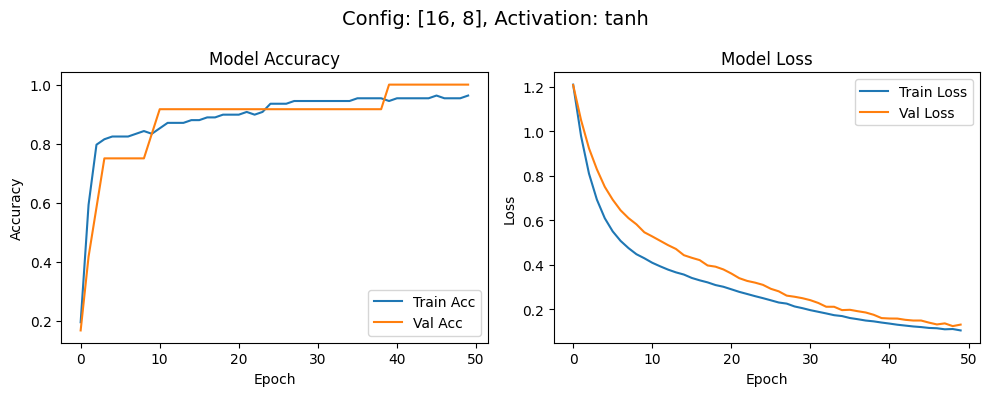


Testing MLP with hidden_layers=[16, 8], activation=sigmoid
Test Accuracy: 0.9000, Test Loss: 0.4084


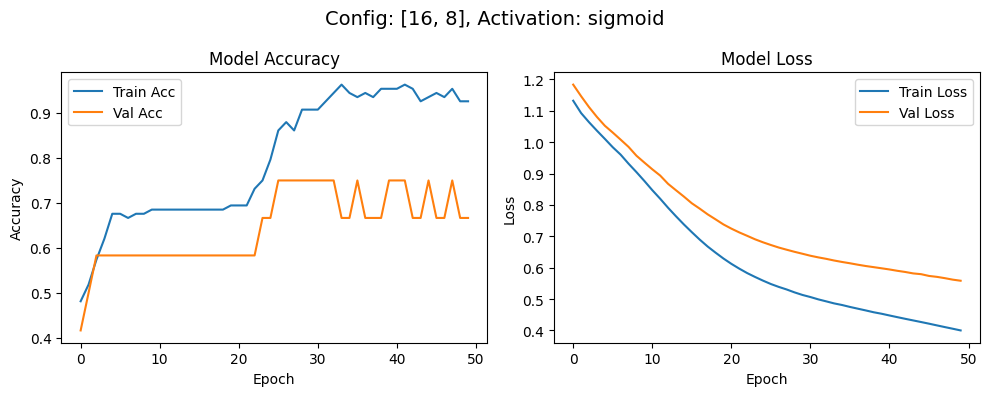


Testing MLP with hidden_layers=[32, 16, 8], activation=relu
Test Accuracy: 0.9667, Test Loss: 0.0674


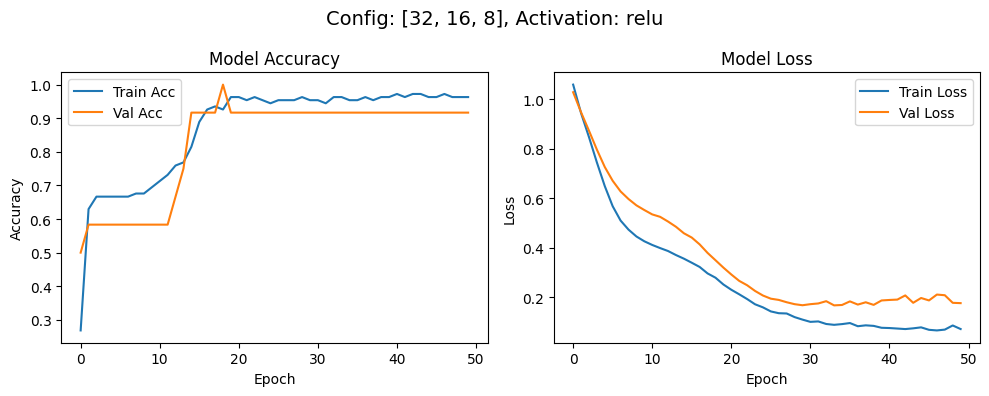


Testing MLP with hidden_layers=[32, 16, 8], activation=tanh
Test Accuracy: 1.0000, Test Loss: 0.0536


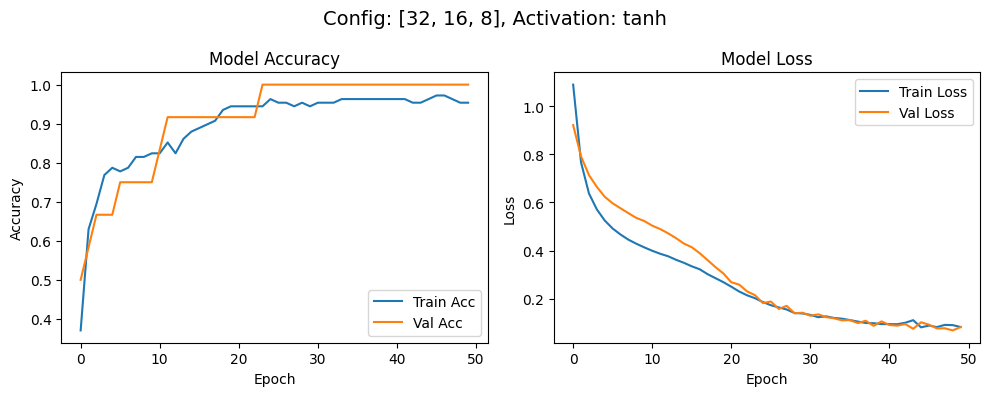


Testing MLP with hidden_layers=[32, 16, 8], activation=sigmoid
Test Accuracy: 0.9333, Test Loss: 0.3481


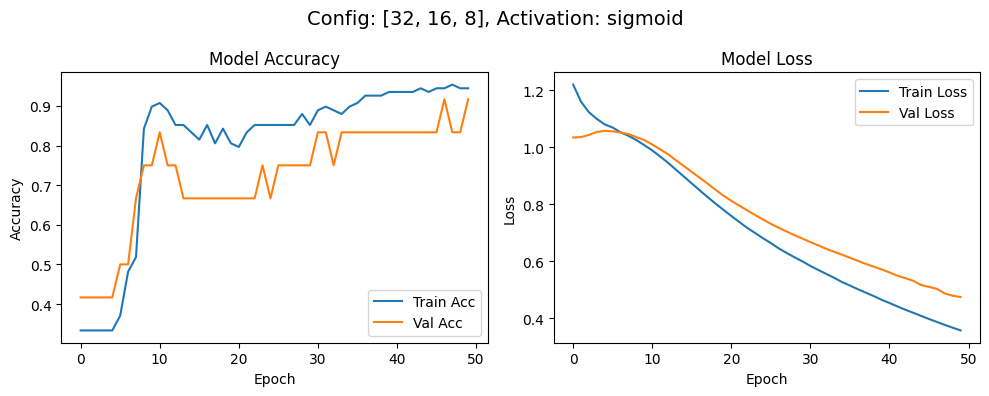

Sepal length (cm): 5.1
Sepal width (cm): 3.5
Petal length (cm): 1.4
Petal width (cm): 0.2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step

🌸 Predicted Iris Species: setosa


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target.reshape(-1, 1)
classes = iris.target_names

# One-hot encoding
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42
)


# Create MLP model
def create_mlp(input_dim, output_dim, hidden_layers, activation='relu'):

    model = Sequential()

    model.add(
        Dense(
            hidden_layers[0],
            input_dim=input_dim,
            activation=activation
        )
    )

    for units in hidden_layers[1:]:
        model.add(Dense(units, activation=activation))

    model.add(Dense(output_dim, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# Different hidden layer configurations
hidden_layer_configs = [
    [8],
    [16, 8],
    [32, 16, 8]
]

# Different activation functions
activations = [
    'relu',
    'tanh',
    'sigmoid'
]


# Train and test different configurations
for hidden_layers in hidden_layer_configs:

    for activation in activations:

        print(
            f"\nTesting MLP with "
            f"hidden_layers={hidden_layers}, "
            f"activation={activation}"
        )

        model = create_mlp(
            input_dim=4,
            output_dim=3,
            hidden_layers=hidden_layers,
            activation=activation
        )

        history = model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=5,
            verbose=0,
            validation_split=0.1
        )

        # Evaluate model
        test_loss, test_acc = model.evaluate(
            X_test,
            y_test,
            verbose=0
        )

        print(
            f"Test Accuracy: {test_acc:.4f}, "
            f"Test Loss: {test_loss:.4f}"
        )

        # Plot accuracy and loss
        plt.figure(figsize=(10, 4))

        plt.suptitle(
            f"Config: {hidden_layers}, "
            f"Activation: {activation}",
            fontsize=14
        )

        # Accuracy plot
        plt.subplot(1, 2, 1)

        plt.plot(
            history.history['accuracy'],
            label='Train Acc'
        )

        plt.plot(
            history.history['val_accuracy'],
            label='Val Acc'
        )

        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Model Accuracy')
        plt.legend()

        # Loss plot
        plt.subplot(1, 2, 2)

        plt.plot(
            history.history['loss'],
            label='Train Loss'
        )

        plt.plot(
            history.history['val_loss'],
            label='Val Loss'
        )

        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Model Loss')
        plt.legend()

        plt.tight_layout()
        plt.show()


# User input for prediction
sepal_length = float(input("Sepal length (cm): "))
sepal_width = float(input("Sepal width (cm): "))
petal_length = float(input("Petal length (cm): "))
petal_width = float(input("Petal width (cm): "))

user_input = np.array([
    [sepal_length,
     sepal_width,
     petal_length,
     petal_width]
])

# Scale user input
user_input_scaled = scaler.transform(user_input)

# Predict using the last trained model
prediction = model.predict(user_input_scaled)

predicted_class_index = np.argmax(prediction)

predicted_class_name = classes[predicted_class_index]

print(
    f"\n🌸 Predicted Iris Species: "
    f"{predicted_class_name}"
)